# 🏠 House Price Prediction with Location Features
### Task 6 — GeoAI / Machine Learning

**What we do in this notebook:**
1. Load a housing dataset with geospatial features
2. Explore and visualize the data
3. Train **Linear Regression** model
4. Train **Gradient Boosting** model
5. Compare both models
6. See which features matter most

**Geospatial features used:**
- Distance to city center (km)
- Distance to nearest school (km)
- Distance to nearest park (km)
- Latitude & Longitude coordinates

---
## Step 1: Install Libraries
Run this cell only **once**. After that you never need to run it again.

In [1]:
# Run once to install everything needed
!pip install pandas numpy scikit-learn matplotlib seaborn

---
## Step 2: Import Libraries

In [2]:
# Importing all the tools we need

import pandas as pd                        # For loading and working with data
import numpy as np                         # For math operations
import matplotlib.pyplot as plt            # For drawing graphs
import seaborn as sns                      # For prettier graphs

from sklearn.model_selection import train_test_split   # Split data into train/test
from sklearn.linear_model import LinearRegression      # Model 1
from sklearn.ensemble import GradientBoostingRegressor # Model 2
from sklearn.preprocessing import LabelEncoder         # Convert text to numbers
from sklearn.metrics import mean_absolute_error, r2_score  # Measure accuracy

import warnings
warnings.filterwarnings('ignore')  # Hide unnecessary warnings

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Step 3: Load the Dataset

In [3]:
# Load the housing dataset
# Make sure housing_data.csv is in the same folder as this notebook!

df = pd.read_csv('housing_data.csv')

print("✅ Dataset loaded!")
print(f"\nTotal rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names: {list(df.columns)}")

✅ Dataset loaded!

Total rows: 500
Total columns: 11

Column names: ['price', 'bedrooms', 'bathrooms', 'area_sqft', 'house_age_years', 'latitude', 'longitude', 'dist_to_center_km', 'dist_to_school_km', 'dist_to_park_km', 'neighborhood']


In [4]:
# See the first 5 rows of data
df.head()

,price,bedrooms,bathrooms,area_sqft,house_age_years,latitude,longitude,dist_to_center_km,dist_to_school_km,dist_to_park_km,neighborhood
0,3000000,4,2,3437,4,33.58745,73.08982,2.84,2.79,0.12,G-11
1,3000000,5,3,1900,12,33.64507,73.07361,4.97,2.72,1.22,F-10
2,3000000,3,1,3356,28,33.62320,73.05095,3.13,4.27,2.40,PWD
3,3000000,5,2,1240,27,33.60987,73.10138,3.85,4.23,1.83,F-10
4,3000000,5,2,1720,24,33.56560,73.08847,4.52,4.20,0.39,Bahria Town


In [5]:
# Get basic statistics (min, max, average etc.)
df.describe()

,price,bedrooms,bathrooms,area_sqft,house_age_years,latitude,longitude,dist_to_center_km,dist_to_school_km,dist_to_park_km
count,5.000000e+02,500.000000,500.000000,500.000000,500.0000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,3.000344e+06,3.480000,1.968000,2412.884000,15.8480,33.599856,73.068195,4.300320,2.57464,1.616220
std,7.051888e+03,1.122551,0.802661,940.397849,8.3889,0.029869,0.028549,1.586334,1.40601,0.846119
min,3.000000e+06,2.000000,1.000000,811.000000,1.0000,33.550510,73.020460,0.160000,0.20000,0.100000
25%,3.000000e+06,2.000000,1.000000,1554.250000,9.0000,33.574133,73.042912,3.130000,1.31250,0.880000
50%,3.000000e+06,3.500000,2.000000,2480.000000,16.0000,33.601315,73.067185,4.565000,2.57500,1.680000
75%,3.000000e+06,4.000000,3.000000,3252.250000,23.0000,33.625615,73.092632,5.490000,3.80000,2.355000
max,3.157000e+06,5.000000,3.000000,3999.000000,29.0000,33.649300,73.119970,7.920000,4.99000,3.000000


In [6]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print("\n✅ No missing values — data is clean!")

Missing values in each column:
price                0
bedrooms             0
bathrooms            0
area_sqft            0
house_age_years      0
latitude             0
longitude            0
dist_to_center_km    0
dist_to_school_km    0
dist_to_park_km      0
neighborhood         0
dtype: int64

✅ No missing values — data is clean!


---
## Step 4: Explore the Data with Graphs

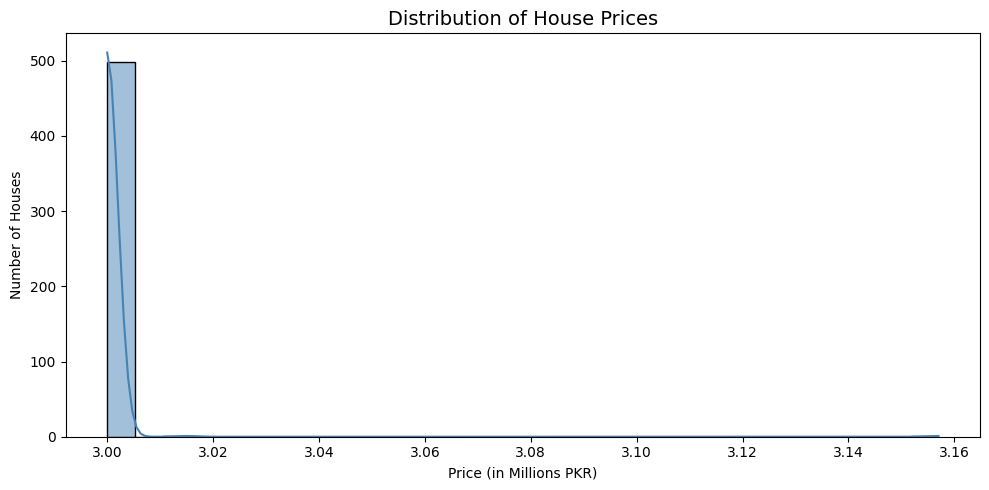

Graph saved as graph1_price_distribution.png


In [7]:
# Graph 1: How are house prices distributed?

plt.figure(figsize=(10, 5))
sns.histplot(df['price'] / 1_000_000, bins=30, color='steelblue', kde=True)
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Price (in Millions PKR)')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('graph1_price_distribution.png', dpi=150)
plt.show()
print("Graph saved as graph1_price_distribution.png")

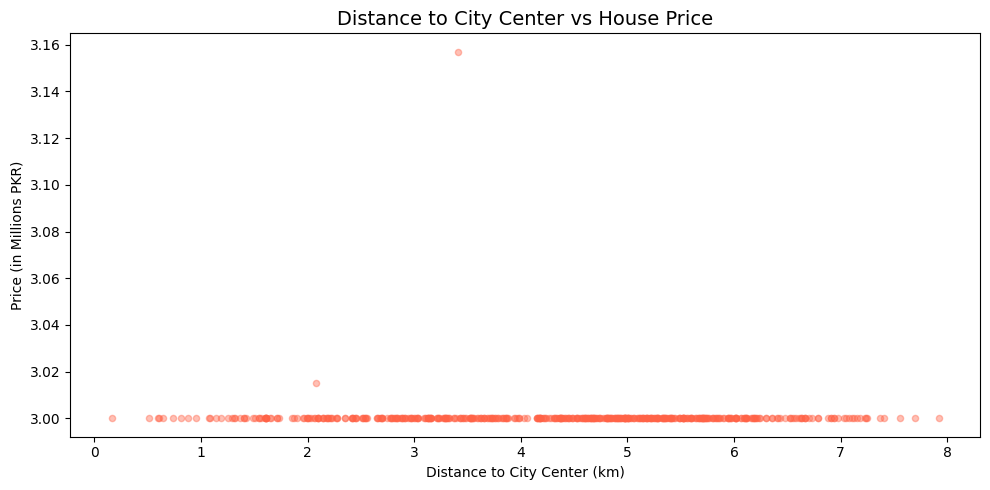

Graph saved as graph2_distance_vs_price.png


In [8]:
# Graph 2: Does distance to city center affect price?

plt.figure(figsize=(10, 5))
plt.scatter(df['dist_to_center_km'], df['price'] / 1_000_000,
            alpha=0.4, color='tomato', s=20)
plt.title('Distance to City Center vs House Price', fontsize=14)
plt.xlabel('Distance to City Center (km)')
plt.ylabel('Price (in Millions PKR)')
plt.tight_layout()
plt.savefig('graph2_distance_vs_price.png', dpi=150)
plt.show()
print("Graph saved as graph2_distance_vs_price.png")

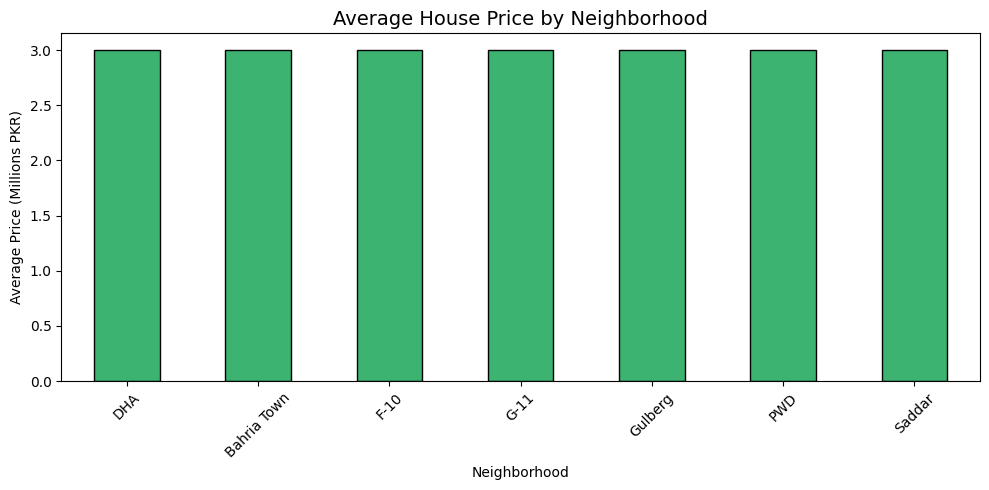

Graph saved as graph3_price_by_neighborhood.png


In [9]:
# Graph 3: Average price by neighborhood

avg_price = df.groupby('neighborhood')['price'].mean().sort_values(ascending=False) / 1_000_000

plt.figure(figsize=(10, 5))
avg_price.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Average House Price by Neighborhood', fontsize=14)
plt.xlabel('Neighborhood')
plt.ylabel('Average Price (Millions PKR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graph3_price_by_neighborhood.png', dpi=150)
plt.show()
print("Graph saved as graph3_price_by_neighborhood.png")

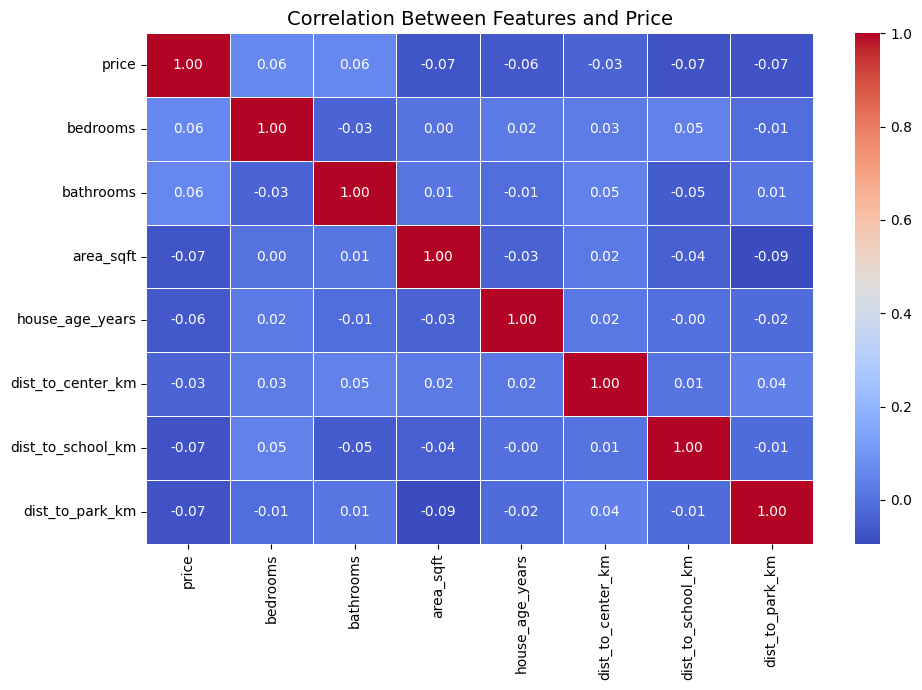

Graph saved as graph4_correlation_heatmap.png


In [10]:
# Graph 4: Correlation heatmap — which features are related to price?

numeric_cols = ['price', 'bedrooms', 'bathrooms', 'area_sqft',
                'house_age_years', 'dist_to_center_km',
                'dist_to_school_km', 'dist_to_park_km']

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Features and Price', fontsize=14)
plt.tight_layout()
plt.savefig('graph4_correlation_heatmap.png', dpi=150)
plt.show()
print("Graph saved as graph4_correlation_heatmap.png")

---
## Step 5: Prepare Data for Machine Learning

In [11]:
# Step 5a: Convert 'neighborhood' text column into numbers
# ML models only understand numbers, not text

le = LabelEncoder()
df['neighborhood_encoded'] = le.fit_transform(df['neighborhood'])

print("Neighborhood encoding:")
for name, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {name} → {code}")

Neighborhood encoding:
  Bahria Town → 0
  DHA → 1
  F-10 → 2
  G-11 → 3
  Gulberg → 4
  PWD → 5
  Saddar → 6


In [12]:
# Step 5b: Choose which columns to use as INPUT (features) and OUTPUT (target)

# Input features — what the model learns from
feature_columns = [
    'bedrooms',
    'bathrooms',
    'area_sqft',
    'house_age_years',
    'latitude',              # Geospatial feature
    'longitude',             # Geospatial feature
    'dist_to_center_km',     # Geospatial feature
    'dist_to_school_km',     # Geospatial feature
    'dist_to_park_km',       # Geospatial feature
    'neighborhood_encoded'
]

X = df[feature_columns]   # Input (features)
y = df['price']           # Output (what we want to predict)

print(f"Input shape: {X.shape}   ← {X.shape[0]} houses, {X.shape[1]} features each")
print(f"Output shape: {y.shape}  ← one price per house")

Input shape: (500, 10)   ← 500 houses, 10 features each
Output shape: (500,)  ← one price per house


In [13]:
# Step 5c: Split into Training data and Testing data
# 80% for training, 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to testing
    random_state=42     # Makes results repeatable
)

print(f"Training data:  {len(X_train)} houses  ← model learns from these")
print(f"Testing data:   {len(X_test)} houses   ← model is tested on these")

Training data:  400 houses  ← model learns from these
Testing data:   100 houses   ← model is tested on these


---
## Step 6: Model 1 — Linear Regression
Simple model. Draws a straight line through the data to predict prices.

In [14]:
# Train Linear Regression model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)   # Model learns from training data

print("✅ Linear Regression model trained!")

✅ Linear Regression model trained!


In [15]:
# Test the model and measure accuracy

lr_predictions = lr_model.predict(X_test)   # Predict prices on test data

lr_mae = mean_absolute_error(y_test, lr_predictions)   # Average error in PKR
lr_r2  = r2_score(y_test, lr_predictions)              # Accuracy score (0 to 1)

print("📊 Linear Regression Results:")
print(f"   R² Score (Accuracy):   {lr_r2:.4f}  ← closer to 1.0 is better")
print(f"   Mean Absolute Error:   PKR {lr_mae:,.0f}  ← average prediction error")

📊 Linear Regression Results:
   R² Score (Accuracy):   -0.7471  ← closer to 1.0 is better
   Mean Absolute Error:   PKR 1,371  ← average prediction error


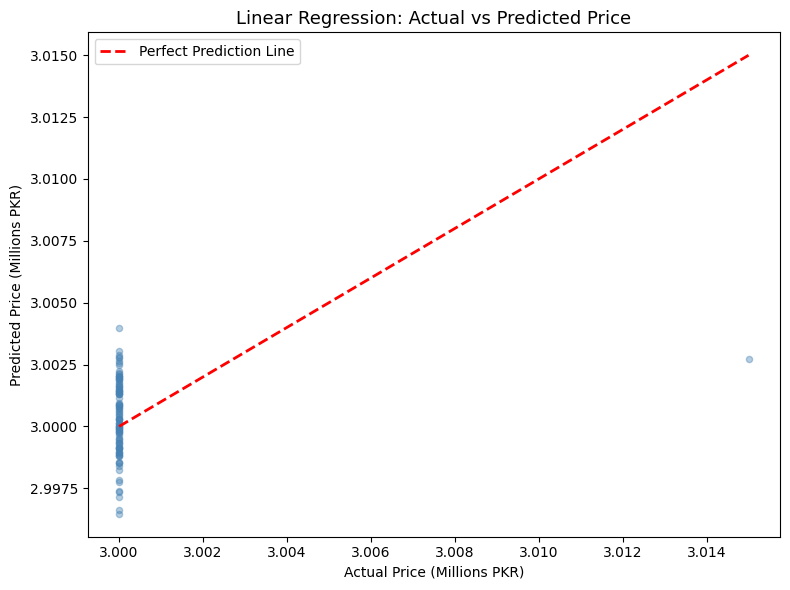

In [16]:
# Graph: Actual prices vs Predicted prices (Linear Regression)

plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1_000_000, lr_predictions / 1_000_000,
            alpha=0.4, color='steelblue', s=20)
plt.plot([y_test.min()/1e6, y_test.max()/1e6],
         [y_test.min()/1e6, y_test.max()/1e6],
         'r--', linewidth=2, label='Perfect Prediction Line')
plt.title('Linear Regression: Actual vs Predicted Price', fontsize=13)
plt.xlabel('Actual Price (Millions PKR)')
plt.ylabel('Predicted Price (Millions PKR)')
plt.legend()
plt.tight_layout()
plt.savefig('graph5_lr_actual_vs_predicted.png', dpi=150)
plt.show()

---
## Step 7: Model 2 — Gradient Boosting
Advanced model. Builds many decision trees and combines them for better accuracy.

In [17]:
# Train Gradient Boosting model

gb_model = GradientBoostingRegressor(
    n_estimators=200,    # Number of trees to build
    learning_rate=0.1,   # How fast it learns
    max_depth=4,         # How deep each tree goes
    random_state=42
)
gb_model.fit(X_train, y_train)

print("✅ Gradient Boosting model trained!")

✅ Gradient Boosting model trained!


In [18]:
# Test Gradient Boosting and measure accuracy

gb_predictions = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_r2  = r2_score(y_test, gb_predictions)

print("📊 Gradient Boosting Results:")
print(f"   R² Score (Accuracy):   {gb_r2:.4f}  ← closer to 1.0 is better")
print(f"   Mean Absolute Error:   PKR {gb_mae:,.0f}  ← average prediction error")

📊 Gradient Boosting Results:
   R² Score (Accuracy):   -0.0101  ← closer to 1.0 is better
   Mean Absolute Error:   PKR 150  ← average prediction error


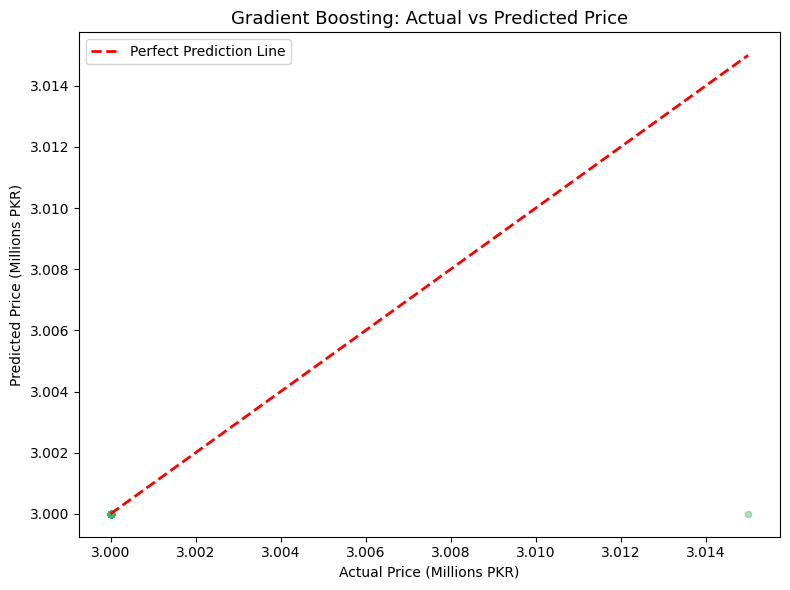

In [19]:
# Graph: Actual prices vs Predicted prices (Gradient Boosting)

plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1_000_000, gb_predictions / 1_000_000,
            alpha=0.4, color='mediumseagreen', s=20)
plt.plot([y_test.min()/1e6, y_test.max()/1e6],
         [y_test.min()/1e6, y_test.max()/1e6],
         'r--', linewidth=2, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Actual vs Predicted Price', fontsize=13)
plt.xlabel('Actual Price (Millions PKR)')
plt.ylabel('Predicted Price (Millions PKR)')
plt.legend()
plt.tight_layout()
plt.savefig('graph6_gb_actual_vs_predicted.png', dpi=150)
plt.show()

---
## Step 8: Compare Both Models Side by Side

In [20]:
# Comparison table

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting'],
    'R² Score': [round(lr_r2, 4), round(gb_r2, 4)],
    'Mean Absolute Error (PKR)': [f"{lr_mae:,.0f}", f"{gb_mae:,.0f}"]
})

print("📊 MODEL COMPARISON")
print("=" * 55)
print(comparison.to_string(index=False))
print("=" * 55)

if gb_r2 > lr_r2:
    print("\n🏆 Winner: Gradient Boosting is more accurate!")
else:
    print("\n🏆 Winner: Linear Regression performed better!")

📊 MODEL COMPARISON
            Model  R² Score Mean Absolute Error (PKR)
Linear Regression   -0.7471                     1,371
Gradient Boosting   -0.0101                       150

🏆 Winner: Gradient Boosting is more accurate!


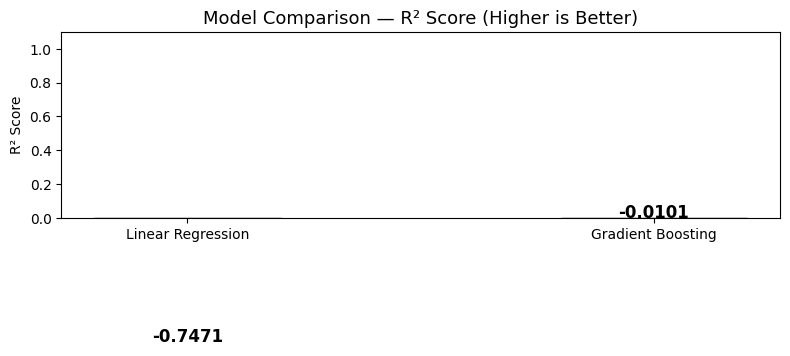

In [21]:
# Graph: Compare R² scores visually

models = ['Linear Regression', 'Gradient Boosting']
r2_scores = [lr_r2, gb_r2]
colors = ['steelblue', 'mediumseagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, r2_scores, color=colors, edgecolor='black', width=0.4)

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{score:.4f}',
             ha='center', fontsize=12, fontweight='bold')

plt.title('Model Comparison — R² Score (Higher is Better)', fontsize=13)
plt.ylabel('R² Score')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('graph7_model_comparison.png', dpi=150)
plt.show()

---
## Step 9: Feature Importance — Which Feature Affects Price Most?

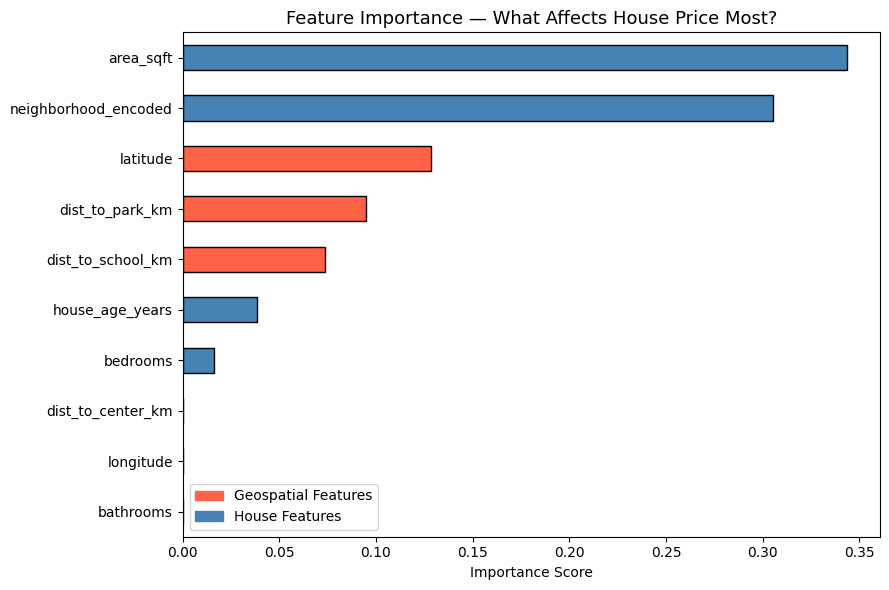

In [22]:
# Feature importance from Gradient Boosting model

importance = pd.Series(gb_model.feature_importances_, index=feature_columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors_bar = ['tomato' if 'dist' in col or col in ['latitude', 'longitude']
               else 'steelblue' for col in importance.index]
importance.plot(kind='barh', color=colors_bar, edgecolor='black')
plt.title('Feature Importance — What Affects House Price Most?', fontsize=13)
plt.xlabel('Importance Score')
plt.axvline(x=0, color='black', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='tomato', label='Geospatial Features'),
    Patch(color='steelblue', label='House Features')
]
plt.legend(handles=legend)
plt.tight_layout()
plt.savefig('graph8_feature_importance.png', dpi=150)
plt.show()

---
## Step 10: Predict Price for a New House
Try predicting the price of a house you describe manually!

In [23]:
# Predict price for a custom house
# Change the values below to try different houses!

new_house = pd.DataFrame([{
    'bedrooms': 4,
    'bathrooms': 2,
    'area_sqft': 2000,
    'house_age_years': 5,
    'latitude': 33.61,
    'longitude': 73.07,
    'dist_to_center_km': 2.5,
    'dist_to_school_km': 1.2,
    'dist_to_park_km': 0.8,
    'neighborhood_encoded': 1   # 0=Bahria Town, 1=DHA, 2=F-10 etc.
}])

lr_pred  = lr_model.predict(new_house)[0]
gb_pred  = gb_model.predict(new_house)[0]

print("🏠 New House Details:")
print(f"   Bedrooms: 4 | Bathrooms: 2 | Area: 2000 sqft")
print(f"   Age: 5 years | Distance to Center: 2.5 km")
print()
print("💰 Predicted Prices:")
print(f"   Linear Regression:   PKR {lr_pred:,.0f}  ({lr_pred/1e6:.2f} Million)")
print(f"   Gradient Boosting:   PKR {gb_pred:,.0f}  ({gb_pred/1e6:.2f} Million)")

🏠 New House Details:
   Bedrooms: 4 | Bathrooms: 2 | Area: 2000 sqft
   Age: 5 years | Distance to Center: 2.5 km

💰 Predicted Prices:
   Linear Regression:   PKR 3,003,575  (3.00 Million)
   Gradient Boosting:   PKR 3,000,000  (3.00 Million)


---
## Summary

| Step | What we did |
|------|-------------|
| Data Loading | Loaded 500 houses with geospatial features |
| Exploration | Visualized price distributions and correlations |
| Preprocessing | Encoded neighborhood, split train/test 80/20 |
| Model 1 | Trained Linear Regression |
| Model 2 | Trained Gradient Boosting |
| Comparison | Compared R² scores and MAE |
| Geospatial Value | Showed how location features impact price |

**Key Geospatial Features Used:**
- `dist_to_center_km` — farther from city = lower price
- `dist_to_school_km` — farther from school = lower price  
- `dist_to_park_km` — farther from park = slightly lower price
- `latitude` / `longitude` — raw coordinates for spatial patterns